Using the Lane Emden equation

$\frac{1}{\xi^2}\frac{d}{d\xi}\left(\xi^2\frac{d\theta}{d\xi}\right) = -\xi^n$,

and using the $n=1$ solution, we get

$\theta = \frac{\sin\xi}{\xi}$

with $\xi_1 = \pi$ as the first zero. The mass enclosed between $\xi_1 = \alpha \xi_2$ and $\xi_2 = \pi$ is then

$dM = 4\pi A^3\rho_c\left(\sin\xi' - \xi'\cos\xi'\right)_{\xi_1}^{\xi_2}$

where $A^2 = (n+1)K\rho_c^{(1-n)/n}/4\pi G$, and $r=A\xi$. To find the central density $\rho_c$, use 

$\frac{\bar{\rho}}{\rho_c} = \left(-\frac{3}{\xi'}\frac{d\theta}{d\xi'}\right)_0^{\xi_1}$,

which, for $n=1$, becomes $\rho_c = \pi^2\bar{\rho}/3$, where $\bar{\rho} = 3M/4\pi R^3$ is the mean density. Using this and $A = R/z_1 = R/\pi$ gives

$dM = \frac{M}{\pi}(\alpha\pi\cos\alpha\pi - \sin\alpha\pi + \pi)$

where $\alpha = R_{\rm min}/R$. We can either find the enclosed mass for a given value of $\alpha$, or find the $\alpha$ for a particularly desired enclosed mass.


In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import fsolve

M_sol = 1.989e30
M_star = 1.4*M_sol
R_star = 1e4
G = 6.67e-11
n = 1
z_1 = np.pi
A = R_star/z_1
alpha = 0.995
rho_c_frac = np.pi**2/3
rho_mean = M_star/(4/3*np.pi*R_star**3)
rho_c = rho_mean*rho_c_frac

target_mass_frac = 1.e-7

dM = M_star/np.pi*(alpha*np.pi*np.cos(alpha*np.pi) - np.sin(alpha*np.pi) + np.pi)

def solve_eqn(x):
    return target_mass_frac - (x*np.pi*np.cos(x*np.pi) - np.sin(x*np.pi) + np.pi)/np.pi

def enclosed_mass(x):
    return (x*np.pi*np.cos(x*np.pi) - np.sin(x*np.pi) + np.pi)/np.pi

initial_guess = 0.995
solution, info, status, msg = fsolve(solve_eqn, initial_guess, full_output=True)

print(f"For M/M_star = {enclosed_mass(solution[0]):0.5e}")
print(f"alpha = {solution[0]:.8f}")


For M/M_star = 1.00000e-07
alpha = 0.99985764


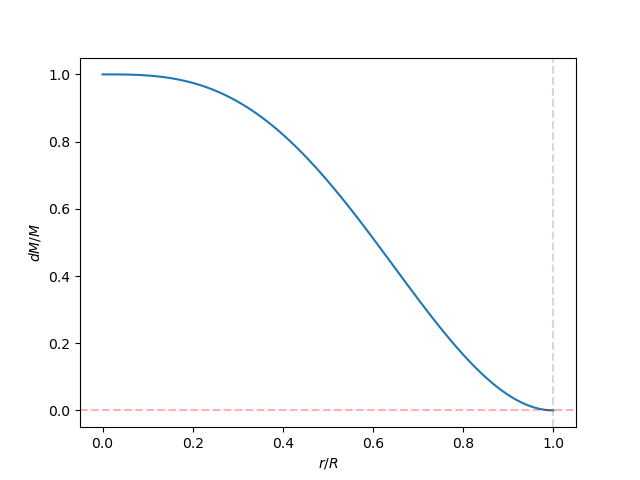

In [2]:
alpha_plot = np.linspace(0,1,100)
encl_mass = M_star/np.pi*(alpha_plot*np.pi*np.cos(alpha_plot*np.pi) - np.sin(alpha_plot*np.pi) + np.pi)

%matplotlib widget
fig,ax = plt.subplots()
ax.plot(alpha_plot,encl_mass/M_star)
ax.axvline(alpha, linestyle='--',alpha = 0.3, c='grey')
ax.axhline(dM/M_star, linestyle='--',alpha = 0.3, c='red')
ax.set(xlabel=r'$r/R$', ylabel = r'$dM/M$')
plt.show()